# A "spell" system

This notebook demonstrates x4c's "spell" system: a concise string-based syntax for requesting diagnostics from CESM outputs.
A "spell" encodes the variable, operation, and region (for example, 'TS:ann:gm' means global-mean annual timeseries).
Use the examples below to compute, inspect, and plot diagnostics generated by x4c.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import x4c
import datetime

os.chdir('/glade/u/home/fengzhu/Github/x4c/docsrc/notebooks')
print(x4c.__version__)
print(f'Last Update: {datetime.date.today()}')

2026.3.9
Last Update: 2026-03-09


In [2]:
dirpath = './b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005'
case = x4c.Timeseries(dirpath, grid_dict={'atm': 'ne16np4'}, cesm_ver=1)

>>> case.root_dir: /glade/u/home/fengzhu/Github/x4c/docsrc/notebooks/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.path_pattern: comp/proc/tseries/*/casename.hstr.vn.timespan.nc
>>> case.grid_dict: {'atm': 'ne16np4', 'ocn': 'g16', 'lnd': 'ne16np4', 'rof': 'ne16np4', 'ice': 'g16'}
>>> case.casename: b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.paths["atm"]["cam.h0"] created
>>> case.paths["ocn"]["pop.h"] created
>>> case.paths["lnd"]["clm2.h0"] created
>>> case.paths["rof"]["rtm.h0"] created
>>> case.paths["ice"]["cice.h"] created
>>> case.vns["atm"]["cam.h0"] created
>>> case.vns["ocn"]["pop.h"] created
>>> case.vns["lnd"]["clm2.h0"] created
>>> case.vns["rof"]["rtm.h0"] created
>>> case.vns["ice"]["cice.h"] created


## A 1st order variable that exists under the CESM Postprocessing Timeseries directory

In [3]:
spell = 'TS'
case.calc(spell)
case.diags[spell]

>>> case.ds["TS"] created
>>> case.diags["TS"] created


<xarray.DataArray 'TS' (time: 600, ncol: 13826)> Size: 33MB
array([[30.723846, 30.15387 , 29.340027, ..., 20.610352, 17.8833  ,
        18.761658],
       [31.421326, 31.069   , 30.561584, ..., 19.588074, 17.21759 ,
        18.28897 ],
       [31.425201, 31.07251 , 30.54779 , ..., 19.613098, 18.46637 ,
        19.39978 ],
       ...,
       [25.155579, 24.095459, 22.823944, ..., 29.183075, 27.860046,
        28.439423],
       [27.179352, 26.204254, 24.977203, ..., 25.29721 , 22.786072,
        23.526276],
       [29.186981, 28.433838, 27.424072, ..., 21.56839 , 19.447754,
        20.136566]], shape=(600, 13826), dtype=float32)
Coordinates:
  * time     (time) object 5kB 8951-01-01 00:00:00 ... 9000-12-01 00:00:00
    lat      (ncol) float64 111kB -35.26 -35.98 -37.07 ... 37.91 37.91 36.74
    lon      (ncol) float64 111kB 315.0 316.6 319.1 320.6 ... 132.5 137.5 135.0
Dimensions without coordinates: ncol
Attributes:
    units:         °C
    long_name:     Surface temperature (radiative)
    cell_methods:  time: mean
    path:          /glade/u/home/fengzhu/Github/x4c/docsrc/notebooks/b.e13.B1...
    gw:            <xarray.DataArray 'area' (ncol: 13826)> Size: 111kB\narray...
    lat:           <xarray.DataArray 'lat' (ncol: 13826)> Size: 111kB\n[13826...
    lon:           <xarray.DataArray 'lon' (ncol: 13826)> Size: 111kB\n[13826...
    comp:          atm
    grid:          ne16np4

## A deduced variable based on 1st order variables

In [4]:
spell = 'LST'
case.calc(spell)
case.diags[spell]

>>> LST is a supported derived variable.
>>> case.ds["TS"] already loaded; to reload, run case.load("TS", ..., reload=True).
>>> case.ds["LANDFRAC"] created
>>> case.ds["LST"] created
>>> case.diags["LST"] created


<xarray.DataArray 'LST' (time: 600, ncol: 13826)> Size: 33MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(600, 13826), dtype=float32)
Coordinates:
  * time     (time) object 5kB 8951-01-01 00:00:00 ... 9000-12-01 00:00:00
    lat      (ncol) float64 111kB -35.26 -35.98 -37.07 ... 37.91 37.91 36.74
    lon      (ncol) float64 111kB 315.0 316.6 319.1 320.6 ... 132.5 137.5 135.0
Dimensions without coordinates: ncol
Attributes:
    units:         °C
    long_name:     Land Surface Temperature
    cell_methods:  time: mean
    path:          /glade/u/home/fengzhu/Github/x4c/docsrc/notebooks/b.e13.B1...
    gw:            <xarray.DataArray 'area' (ncol: 13826)> Size: 111kB\narray...
    lat:           <xarray.DataArray 'lat' (ncol: 13826)> Size: 111kB\n[13826...
    lon:           <xarray.DataArray 'lon' (ncol: 13826)> Size: 111kB\n[13826...
    comp:          atm
    grid:          ne16np4
    vn:            LST

In [5]:
spell = 'd18Op'
case.calc(spell)
case.diags[spell]

>>> d18Op is a supported derived variable.
>>> case.ds["PRECRC_H216Or"] created
>>> case.ds["PRECSC_H216Os"] created
>>> case.ds["PRECRL_H216OR"] created
>>> case.ds["PRECSL_H216OS"] created
>>> case.ds["PRECRC_H218Or"] created
>>> case.ds["PRECSC_H218Os"] created
>>> case.ds["PRECRL_H218OR"] created
>>> case.ds["PRECSL_H218OS"] created
>>> case.ds["d18Op"] created
>>> case.diags["d18Op"] created


<xarray.DataArray 'd18Op' (time: 600, ncol: 13826)> Size: 33MB
array([[-3.9242506, -4.0639043, -4.1208863, ..., -9.632945 , -8.070588 ,
        -8.230329 ],
       [-5.675137 , -5.547166 , -5.905688 , ..., -8.86035  , -8.010567 ,
        -7.663846 ],
       [-4.2343736, -4.4196844, -4.8832297, ..., -7.989228 , -7.1674585,
        -6.616235 ],
       ...,
       [-4.006505 , -4.380405 , -5.3446293, ..., -5.651295 , -5.3805113,
        -5.291581 ],
       [-3.416419 , -4.7590733, -4.9126744, ..., -8.602322 , -6.9465637,
        -6.7592263],
       [-3.531158 , -3.5579205, -3.6706924, ..., -8.005201 , -7.1768165,
        -6.878078 ]], shape=(600, 13826), dtype=float32)
Coordinates:
  * time     (time) object 5kB 8951-01-01 00:00:00 ... 9000-12-01 00:00:00
    lat      (ncol) float64 111kB -35.26 -35.98 -37.07 ... 37.91 37.91 36.74
    lon      (ncol) float64 111kB 315.0 316.6 319.1 320.6 ... 132.5 137.5 135.0
Dimensions without coordinates: ncol
Attributes:
    units:         permil
    long_name:     Precipitation d18O
    cell_methods:  time: mean
    path:          /glade/u/home/fengzhu/Github/x4c/docsrc/notebooks/b.e13.B1...
    gw:            <xarray.DataArray 'area' (ncol: 13826)> Size: 111kB\narray...
    lat:           <xarray.DataArray 'lat' (ncol: 13826)> Size: 111kB\n[13826...
    lon:           <xarray.DataArray 'lon' (ncol: 13826)> Size: 111kB\n[13826...
    comp:          atm
    grid:          ne16np4
    vn:            d18Op

## Climatology

In [6]:
spell = 'TS:climo:gm'
case.calc(spell)
case.diags[spell]

>>> Variable `TS` is already calculated and the calculation is skipped.
>>> Timespan: [8951-01-01 00:00:00, 9000-12-01 00:00:00]
>>> case.diags["TS:climo:gm"] created


<xarray.DataArray 'TS' (time: 12)> Size: 96B
array([22.95040876, 23.45636378, 23.9469648 , 24.34329028, 24.78539403,
       25.38467318, 25.82864283, 25.74886232, 25.08311286, 24.10669313,
       23.1864649 , 22.72951153])
Coordinates:
  * time     (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    units:         °C
    long_name:     Global Mean Surface temperature (radiative) (Climatology)
    cell_methods:  time: mean
    path:          /glade/u/home/fengzhu/Github/x4c/docsrc/notebooks/b.e13.B1...
    gw:            <xarray.DataArray 'area' (ncol: 13826)> Size: 111kB\narray...
    lat:           <xarray.DataArray 'lat' (ncol: 13826)> Size: 111kB\n[13826...
    lon:           <xarray.DataArray 'lon' (ncol: 13826)> Size: 111kB\n[13826...
    comp:          atm
    grid:          ne16np4
    climo_period:  (np.int64(8951), np.int64(9000))

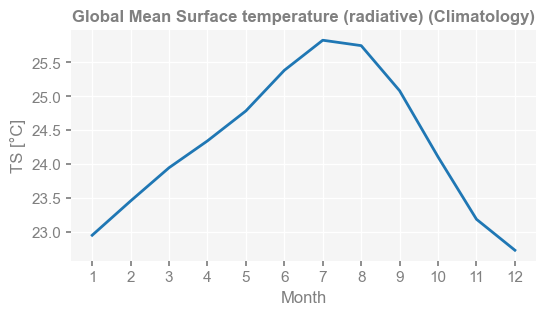

In [7]:
x4c.set_style('web', font_scale=1)
fig, ax = case.plot(spell)

## A horizontal 2D map

In [8]:
spell = 'TS:ann'
case.calc(spell)
case.diags[spell]

>>> Variable `TS` is already calculated and the calculation is skipped.
>>> Timespan: [8951-01-01 00:00:00, 9000-12-01 00:00:00]
>>> case.diags["TS:ann"] created


<xarray.DataArray 'TS' (time: 50, ncol: 13826)> Size: 3MB
array([[27.095312, 26.468687, 25.667841, ..., 24.843073, 23.622728,
        24.450674],
       [26.876898, 26.190992, 25.369055, ..., 24.968979, 23.625565,
        24.622602],
       [27.404486, 26.787392, 25.993246, ..., 24.89312 , 23.81645 ,
        24.575073],
       ...,
       [27.478502, 26.83081 , 26.000784, ..., 24.397955, 23.188248,
        24.005974],
       [27.604712, 26.873049, 25.939466, ..., 24.391893, 23.050173,
        24.072235],
       [27.74832 , 27.028776, 26.09156 , ..., 25.60959 , 24.387312,
        25.152489]], shape=(50, 13826), dtype=float32)
Coordinates:
    lat      (ncol) float64 111kB -35.26 -35.98 -37.07 ... 37.91 37.91 36.74
    lon      (ncol) float64 111kB 315.0 316.6 319.1 320.6 ... 132.5 137.5 135.0
  * time     (time) object 400B 8951-12-31 00:00:00 ... 9000-12-31 00:00:00
Dimensions without coordinates: ncol
Attributes:
    units:         °C
    long_name:     Surface temperature (radiative) (Annual)
    cell_methods:  time: mean
    path:          /glade/u/home/fengzhu/Github/x4c/docsrc/notebooks/b.e13.B1...
    gw:            <xarray.DataArray 'area' (ncol: 13826)> Size: 111kB\narray...
    lat:           <xarray.DataArray 'lat' (ncol: 13826)> Size: 111kB\n[13826...
    lon:           <xarray.DataArray 'lon' (ncol: 13826)> Size: 111kB\n[13826...
    comp:          atm
    grid:          ne16np4

>>> case.ds["SSH"] created


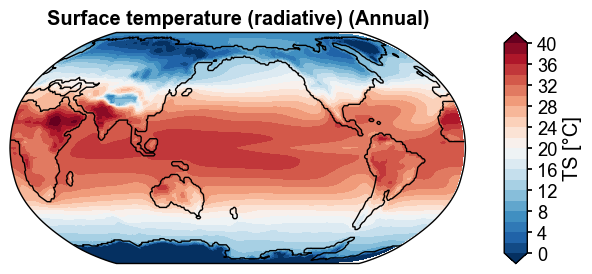

In [9]:
x4c.set_style('journal_spines', font_scale=1.2)
fig, ax = case.plot(spell)

In [10]:
spell = 'SST:-12,1,2'
case.calc(spell)
case.diags[spell]

>>> SST is a supported derived variable.
>>> case.ds["TEMP"] created
>>> case.ds["SST"] created
>>> Timespan: [8951-01-01 00:00:00, 9000-12-01 00:00:00]
>>> case.diags["SST:-12,1,2"] created


<xarray.DataArray 'SST' (time: 51, nlat: 384, nlon: 320)> Size: 25MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(51, 384, 320), dtype=float32)
Coordinates:
    z_t      float32 4B 500.0
    ULONG    (nlat, nlon) float64 983kB 343.5 344.8 346.1 ... 326.4 326.7 327.0
    ULAT     (nlat, nlon) float64 983kB -87.53 -87.52 -87.5 ... 72.64 72.64
    TLONG    (nlat, nlon) float64 983kB 341.6 342.9 344.2 ... 326.2 326.5 326.8
    TLAT     (nlat, nlon) float64 983kB -87.73 -87.72 -87.7 ... 72.52 72.52
  * time     (time) object 408B 8951-02-28 00:00:00 ... 9001-02-28 00:00:00
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     Sea Surface Temperature (DJF)
    units:         °C
    grid_loc:      3111
    cell_methods:  time: mean
    path:          /glade/u/home/fengzhu/Github/x4c/docsrc/notebooks/b.e13.B1...
    gw:            <xarray.DataArray 'TAREA' (nlat: 384, nlon: 320)> Size: 98...
    lat:           <xarray.DataArray 'TLAT' (nlat: 384, nlon: 320)> Size: 983...
    lon:           <xarray.DataArray 'TLONG' (nlat: 384, nlon: 320)> Size: 98...
    dz:            <xarray.DataArray 'dz' (z_t: 60)> Size: 240B\n[60 values w...
    comp:          ocn
    grid:          g16
    vn:            SST

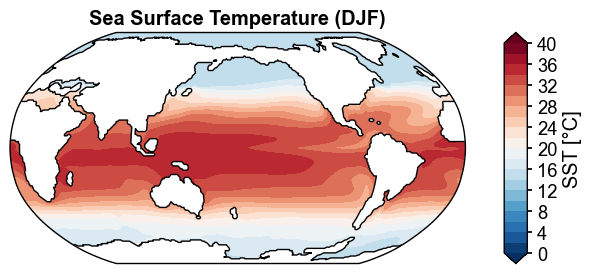

In [11]:
fig, ax = case.plot(spell)

In [12]:
case.calc('MLD:3')
case.calc('MLD:9')

mask = case.diags['MLD:3'].lat > 0
case.diags['MLD:mix'] = case.diags['MLD:3'].mean('time').where(mask, other=case.diags['MLD:9'].mean('time'))

>>> MLD is a supported derived variable.
>>> case.ds["XMXL"] created
>>> case.ds["MLD"] created
>>> Timespan: [8951-01-01 00:00:00, 9000-12-01 00:00:00]
>>> case.diags["MLD:3"] created
>>> MLD is a supported derived variable.
>>> case.ds["XMXL"] already loaded; to reload, run case.load("XMXL", ..., reload=True).
>>> case.ds["MLD"] created
>>> Timespan: [8951-01-01 00:00:00, 9000-12-01 00:00:00]
>>> case.diags["MLD:9"] created


In [13]:
case.diags['MLD:mix']

<xarray.DataArray 'MLD' (nlat: 384, nlon: 320)> Size: 492kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(384, 320), dtype=float32)
Coordinates:
    ULONG    (nlat, nlon) float64 983kB 343.5 344.8 346.1 ... 326.4 326.7 327.0
    ULAT     (nlat, nlon) float64 983kB -87.53 -87.52 -87.5 ... 72.64 72.64
    TLONG    (nlat, nlon) float64 983kB 341.6 342.9 344.2 ... 326.2 326.5 326.8
    TLAT     (nlat, nlon) float64 983kB -87.73 -87.72 -87.7 ... 72.52 72.52
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     Maximum Mixed-Layer Depth (M)
    units:         m
    grid_loc:      2110
    cell_methods:  time: maximum
    path:          /glade/u/home/fengzhu/Github/x4c/docsrc/notebooks/b.e13.B1...
    gw:            <xarray.DataArray 'TAREA' (nlat: 384, nlon: 320)> Size: 98...
    lat:           <xarray.DataArray 'TLAT' (nlat: 384, nlon: 320)> Size: 983...
    lon:           <xarray.DataArray 'TLONG' (nlat: 384, nlon: 320)> Size: 98...
    dz:            <xarray.DataArray 'dz' (z_t: 60)> Size: 240B\n[60 values w...
    comp:          ocn
    grid:          g16
    vn:            MLD

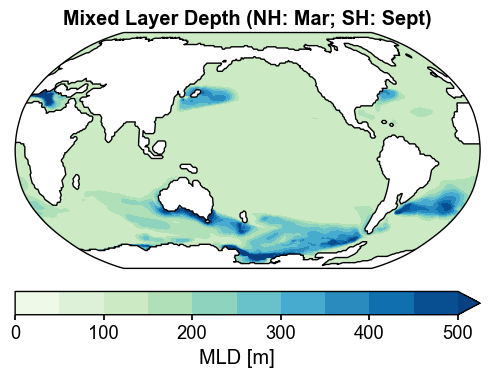

Figure saved at: "figs/map_MLD_mix.pdf"


In [14]:
fig, ax = case.plot(
    'MLD:mix',
    figsize=(6, 6),
    cbar_kwargs={'orientation': 'horizontal', 'aspect': 20, 'pad': 0.05},
)
ax.set_title('Mixed Layer Depth (NH: Mar; SH: Sept)', weight='bold')
x4c.showfig(fig)
x4c.savefig(fig, './figs/map_MLD_mix.pdf')

## A timeseries

In [15]:
spell = 'TS:ann:gm'
case.calc(spell)
case.diags[spell]

>>> Variable `TS` is already calculated and the calculation is skipped.
>>> Timespan: [8951-01-01 00:00:00, 9000-12-01 00:00:00]
>>> case.diags["TS:ann:gm"] created


<xarray.DataArray 'TS' (time: 50)> Size: 400B
array([24.4128289 , 24.52198967, 24.13382052, 24.33224356, 24.4598987 ,
       24.31180457, 24.33586058, 24.1110387 , 24.07948485, 24.22708159,
       24.1367307 , 24.17390508, 24.18800733, 24.09141946, 24.18525948,
       24.49602257, 24.1977737 , 23.97936985, 24.17802306, 24.35568247,
       24.51118634, 24.2515905 , 24.13155237, 24.1675983 , 24.33082636,
       24.2813164 , 24.31966906, 24.433534  , 24.32294183, 24.27283101,
       24.53654344, 24.28373572, 24.09457417, 24.27189317, 24.56742109,
       24.36937101, 24.23502009, 24.3549681 , 24.600416  , 24.54777983,
       24.28243932, 24.28388092, 24.30570442, 24.35778457, 24.37612048,
       24.43264161, 24.24372558, 24.21401955, 24.38051205, 24.12341764])
Coordinates:
  * time     (time) object 400B 8951-12-31 00:00:00 ... 9000-12-31 00:00:00
Attributes:
    units:         °C
    long_name:     Global Mean Surface temperature (radiative) (Annual)
    cell_methods:  time: mean
    path:          /glade/u/home/fengzhu/Github/x4c/docsrc/notebooks/b.e13.B1...
    gw:            <xarray.DataArray 'area' (ncol: 13826)> Size: 111kB\narray...
    lat:           <xarray.DataArray 'lat' (ncol: 13826)> Size: 111kB\n[13826...
    lon:           <xarray.DataArray 'lon' (ncol: 13826)> Size: 111kB\n[13826...
    comp:          atm
    grid:          ne16np4

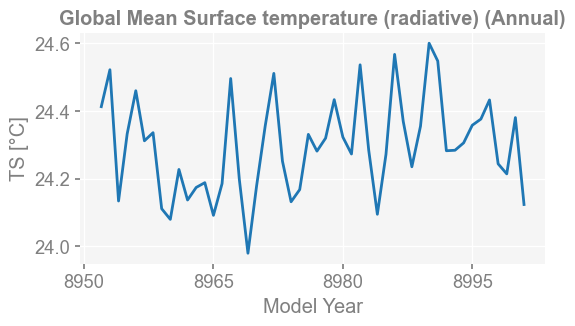

In [16]:
x4c.set_style('web', font_scale=1.2)
fig, ax = case.plot(spell)

## A zonal mean plot

In [17]:
spell = 'LST:ann:zm'
case.calc(spell)
case.diags[spell]

>>> Variable `LST` is already calculated and the calculation is skipped.
>>> Timespan: [8951-01-01 00:00:00, 9000-12-01 00:00:00]
>>> case.diags["LST:ann:zm"] created


<xarray.DataArray 'LST' (time: 50, lat: 180)> Size: 36kB
array([[-17.580034, -18.036827, -17.992954, ...,        nan,        nan,
               nan],
       [-17.275988, -18.02568 , -18.102137, ...,        nan,        nan,
               nan],
       [-18.18247 , -18.830654, -18.876236, ...,        nan,        nan,
               nan],
       ...,
       [-17.469307, -18.135544, -18.18202 , ...,        nan,        nan,
               nan],
       [-16.71525 , -17.500294, -17.598314, ...,        nan,        nan,
               nan],
       [-16.856697, -17.553476, -17.634754, ...,        nan,        nan,
               nan]], shape=(50, 180), dtype=float32)
Coordinates:
  * time     (time) object 400B 8951-12-31 00:00:00 ... 9000-12-31 00:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Attributes:
    units:         °C
    long_name:     Zonal Mean Land Surface Temperature (Annual)
    cell_methods:  time: mean
    path:          /glade/u/home/fengzhu/Github/x4c/docsrc/notebooks/b.e13.B1...
    gw:            <xarray.DataArray 'area' (ncol: 13826)> Size: 111kB\narray...
    lat:           <xarray.DataArray 'lat' (ncol: 13826)> Size: 111kB\n[13826...
    lon:           <xarray.DataArray 'lon' (ncol: 13826)> Size: 111kB\n[13826...
    comp:          atm
    grid:          ne16np4
    vn:            LST

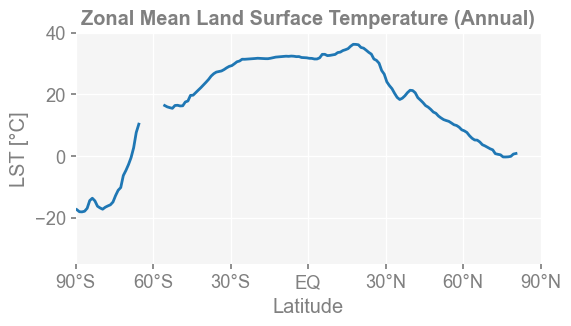

In [18]:
fig, ax = case.plot(spell)

## A vertical 2D plot

In [19]:
spell = 'MOC:ann:yz'
case.calc(spell)
case.diags[spell]

>>> MOC is a supported derived variable.
>>> case.ds["MOC"] created
>>> Timespan: [8951-01-01 00:00:00, 9000-12-01 00:00:00]
>>> case.diags["MOC:ann:yz"] created


<xarray.DataArray 'MOC' (time: 50, z_t: 61, lat: 91)> Size: 1MB
array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -1.94341654e-03, -3.89124529e-04,  1.73436900e-04],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          1.72229052e-01,  9.17188302e-02,  5.70570379e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          2.36894444e-01,  1.23025537e-01,  7.05491826e-02],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          8.16434749e-07,  8.16434749e-07,  8.16434749e-07],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          2.74996466e-07,  2.74996466e-07,  2.74996466e-07],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

       [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -4.55033849e-04, -2.44729948e-04, -7.91880884e-05],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          1.11171342e-01,  6.28634840e-02,  4.01812606e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          1.63042381e-01,  1.01493865e-01,  6.58850148e-02],
...
          7.12094504e-07,  7.12094504e-07,  7.12094504e-07],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -5.03204035e-07, -5.03204035e-07, -5.03204035e-07],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

       [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          1.90572022e-03,  4.49017592e-04, -7.26856306e-05],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          4.07577157e-02,  5.96384890e-02,  6.74766377e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          2.71115452e-02,  7.92309120e-02,  9.72099304e-02],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -1.04821856e-06, -1.04821856e-06, -1.04821856e-06],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -9.27436304e-07, -9.27436304e-07, -9.27436304e-07],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]]],
      shape=(50, 61, 91), dtype=float32)
Coordinates:
    moc_components  |S256 256B b'Eulerian Mean'
  * lat             (lat) float32 364B -90.0 -88.0 -86.0 ... 86.0 88.0 90.0
  * z_t             (z_t) float32 244B 0.0 0.01 0.02 0.03 ... 4.75 5.0 5.25 5.5
  * time            (time) object 400B 8951-12-31 00:00:00 ... 9000-12-31 00:...
Attributes:
    long_name:     Meridional Overturning Circulation (Annual)
    units:         Sverdrups
    cell_methods:  time: mean
    path:          /glade/u/home/fengzhu/Github/x4c/docsrc/notebooks/b.e13.B1...
    gw:            <xarray.DataArray 'TAREA' (nlat: 384, nlon: 320)> Size: 98...
    lat:           <xarray.DataArray 'TLAT' (nlat: 384, nlon: 320)> Size: 983...
    lon:           <xarray.DataArray 'TLONG' (nlat: 384, nlon: 320)> Size: 98...
    dz:            <xarray.DataArray 'dz' (z_t: 60)> Size: 240B\n[60 values w...
    comp:          ocn
    grid:          g16
    lon_name:      Meridional Ocean Circulation
    vn:            MOC

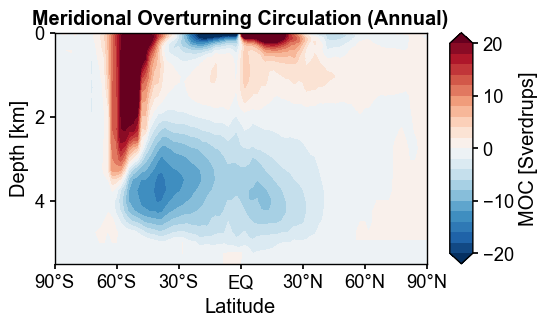

In [20]:
x4c.set_style('journal_spines', font_scale=1.2)
fig, ax = case.plot(spell)